----
----
# **APPENDIX**
Everything below does not need to run, nor can it run. I kept it here for reference only.

In [ ]:
#import pandas as pd
#import numpy as np

#Basic feature statistics to better understand the features
feature_stats = pd.DataFrame(index=X_train_balanced.columns)
feature_stats["Mean"] = X_train_balanced.mean()
feature_stats["Std"] = X_train_balanced.std()
feature_stats["Min"] = X_train_balanced.min()
feature_stats["Max"] = X_train_balanced.max()
feature_stats["Range"] = feature_stats["Max"] - feature_stats["Min"]
feature_stats["Skewness"] = X_train_balanced.skew()
feature_stats["Kurtosis"] = X_train_balanced.kurt()

# Print statistics summary
print("\nFeature Summary Statistics")
print(feature_stats.round(3).sort_values(by="Range", ascending=False).to_string())

#Save to CSV
feature_stats.to_csv("feature_summary_stats.csv")



Feature Summary Statistics
                       Mean  Std    Min     Max   Range  Skewness  Kurtosis
Vibration_ratio        -0.0  1.0 -0.503  18.196  18.699     6.421    58.719
Noise_Vibration_Ratio  -0.0  1.0 -0.487  15.253  15.740     5.650    43.134
Temp_Ratio              0.0  1.0 -1.397   4.939   6.336     1.439     2.365
Pressure_Drop           0.0  1.0 -2.601   2.600   5.201     0.002    -0.463
Amplitude_Energy        0.0  1.0 -1.402   3.561   4.963     0.856     0.162
Freq_Energy             0.0  1.0 -1.345   3.523   4.868     0.891     0.119
Acoustic_Intensity      0.0  1.0 -1.667   2.658   4.325     0.268    -0.790
Intake_Pressure         0.0  1.0 -1.887   1.891   3.779     0.012    -1.059
Amplitude_Mean         -0.0  1.0 -1.901   1.878   3.779    -0.029    -1.041
Vibration_Amplitude     0.0  1.0 -1.860   1.912   3.772     0.026    -1.038
Frequency_Band_Energy   0.0  1.0 -1.882   1.873   3.755    -0.019    -1.070
Surface_Temperature     0.0  1.0 -1.875   1.872   3.748    -

### **Optuna + Universal Approximation Theorem (UAT)**
I would like to try Optuna again, but this time, I will also apply UAT to study the effect of model capacity on accuracy in more detail. This is not exactly the same thing that UAT describes since the other parameters are also changing at the same time, but it should still give me a decent idea of how depth affects accuracy.

In [27]:
# I want to try using Universal Approximation Theorem (UAT)

#import optuna
#import os
#import numpy as np
#import pandas as pd
#from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import f1_score, balanced_accuracy_score
#import matplotlib.pyplot as plt

# Define dimensionality of input features (d + 4 as per UAT depth version)
d = X_train_balanced.shape[1]
width = d + 4  # Fixed width for all layers

def objective(trial):
    # Hyperparameter suggestions (n_layers controls depth for UAT)
    n_layers = trial.suggest_int("n_layers", 10, 50)
    layer_sizes = [width] * n_layers  # Fixed width, variable depth
    learning_rate = trial.suggest_float("learning_rate_init", 1e-5, 1e-1, log=True)
    alpha = trial.suggest_float("alpha", 1e-6, 1e-1, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])

    # Build MLP model
    clf = MLPClassifier(
        hidden_layer_sizes=tuple(layer_sizes),  # UAT-based depth and width
        activation='',
        solver="adam",
        learning_rate_init=learning_rate,
        alpha=alpha,
        max_iter=600,
        early_stopping=True,
        n_iter_no_change=50,
        random_state=42
    )

    # Train and evaluate on validation set
    clf.fit(X_train_balanced, y_train_balanced)

    # Evaluate on training set
    y_train_pred = clf.predict(X_train_balanced)
    train_acc = balanced_accuracy_score(y_train_balanced, y_train_pred)
    train_error = 1 - train_acc

    # Evaluate on test set
    y_val_pred = clf.predict(X_test)
    test_acc = balanced_accuracy_score(y_test, y_val_pred)
    test_error = 1 - test_acc

    # Capture the number of epochs (iterations used)
    n_iter = clf.n_iter_

    # Calculate capacity (width * depth) for analysis
    capacity = width * n_layers

    # Save results to CSV
    result_dict = {
        "n_layers": n_layers,
        "layer_sizes": str(layer_sizes),
        "learning_rate_init": learning_rate,
        "alpha": alpha,
        "activation": activation,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_error": train_error,
        "test_error": test_error,
        "n_iter": n_iter,
        "capacity": capacity  # Add capacity for plotting
    }
    result_df = pd.DataFrame([result_dict])

    # Define CSV path
    csv_path = "mlp_info/mlp_optuna_UAT_results.csv"

    # Check if the CSV exists, create if not
    if os.path.exists(csv_path):
        result_df.to_csv(csv_path, mode="a", header=False, index=False)
    else:
        result_df.to_csv(csv_path, index=False)

    return test_acc

# Run the Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)  # Modified to 5 trials to speed up testing

# Report results
print("Best accuracy Score:", study.best_value)
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")



[I 2025-03-31 16:43:33,494] A new study created in memory with name: no-name-e543a69c-d58c-4c5c-afc0-760f711f8261
[I 2025-03-31 16:44:06,129] Trial 0 finished with value: 0.3035 and parameters: {'n_layers': 36, 'learning_rate_init': 0.013724091704602745, 'alpha': 4.9211556200299725e-05, 'activation': 'logistic'}. Best is trial 0 with value: 0.3035.
[I 2025-03-31 16:44:29,049] Trial 1 finished with value: 0.5965 and parameters: {'n_layers': 27, 'learning_rate_init': 0.007820002970705375, 'alpha': 0.00033149988908101575, 'activation': 'logistic'}. Best is trial 1 with value: 0.5965.
[I 2025-03-31 16:44:47,218] Trial 2 finished with value: 0.1 and parameters: {'n_layers': 21, 'learning_rate_init': 0.010285329925118547, 'alpha': 0.0015193152493496584, 'activation': 'logistic'}. Best is trial 1 with value: 0.5965.
[I 2025-03-31 16:44:59,054] Trial 3 finished with value: 0.1 and parameters: {'n_layers': 23, 'learning_rate_init': 0.03419276090423787, 'alpha': 0.00019892638442713188, 'activati

Best accuracy Score: 0.5965
Best Parameters:
  - n_layers: 27
  - learning_rate_init: 0.007820002970705375
  - alpha: 0.00033149988908101575
  - activation: logistic


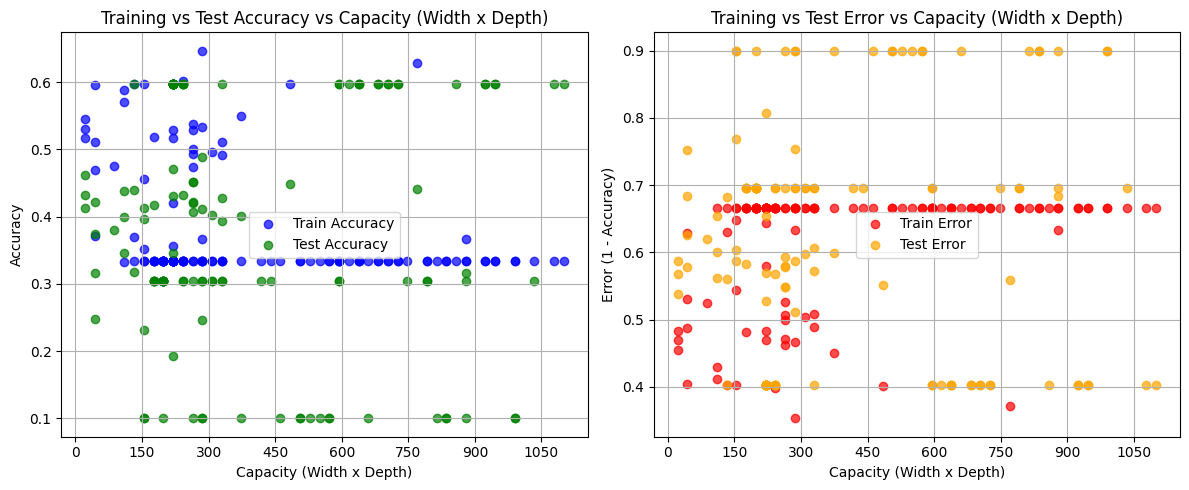

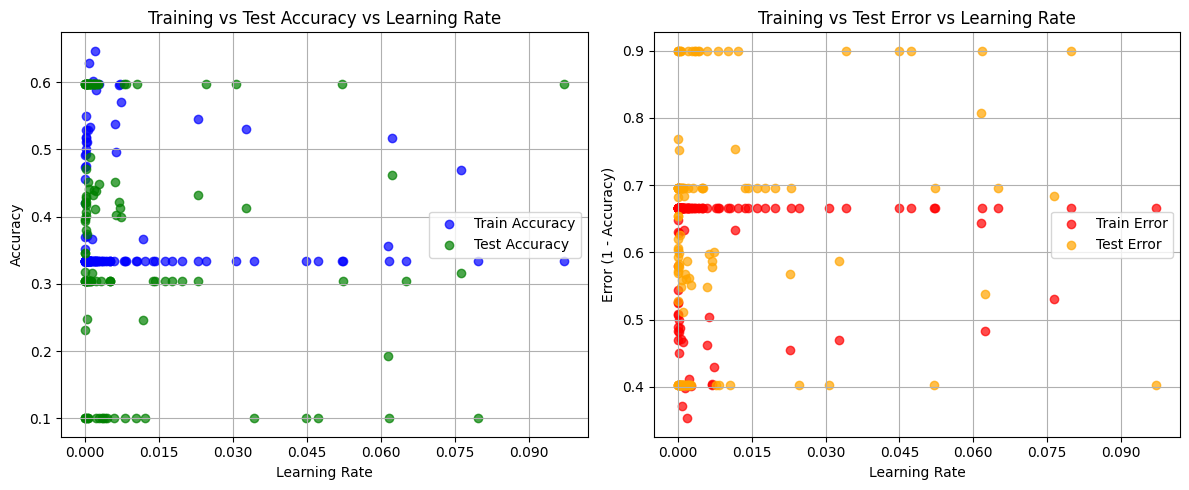

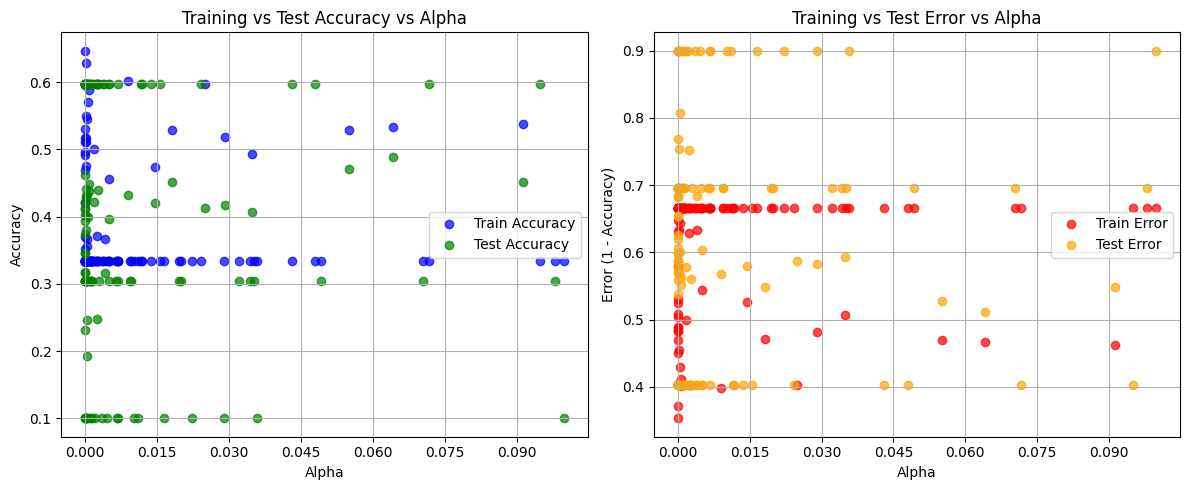

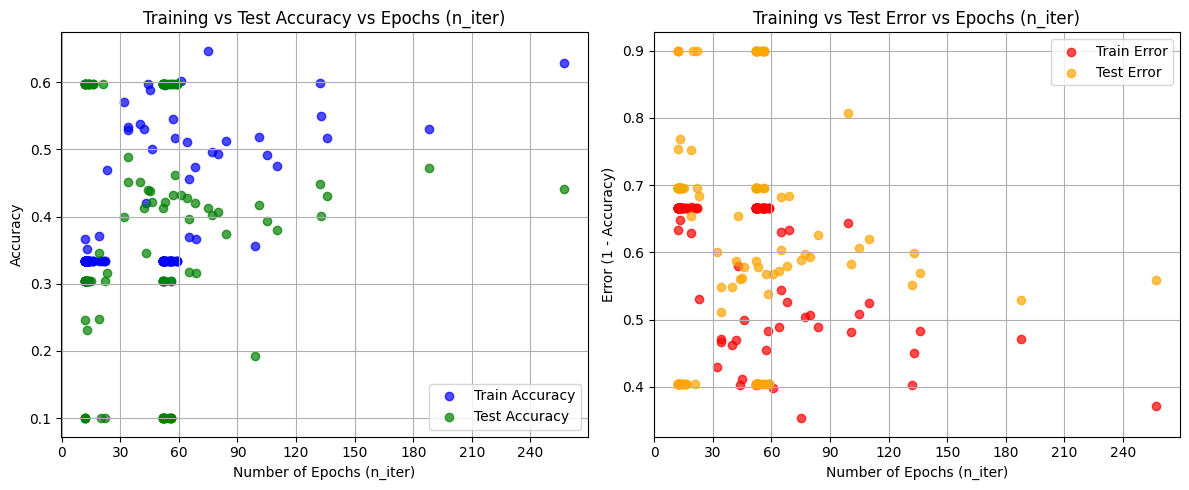

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load Optuna MLP results
df = pd.read_csv("mlp_info/mlp_optuna_UAT_results.csv")  # File name matches previous block

# Define dimensionality of input features and width (UAT depth version)
d = X_train_balanced.shape[1]
df["width"] = d + 4  # Fixed width according to UAT assumption
df["depth"] = df["n_layers"]
df["capacity"] = df["width"] * df["depth"]

# Plotting function for Capacity vs Accuracy/Error
def plot_capacity_vs_metrics(df):
    x = df["capacity"]
    train_acc = df["train_accuracy"]
    test_acc = df["test_accuracy"]
    train_err = df["train_error"]
    test_err = df["test_error"]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].scatter(x, train_acc, color="blue", alpha=0.7, label="Train Accuracy")
    axs[0].scatter(x, test_acc, color="green", alpha=0.7, label="Test Accuracy")
    axs[0].set_title("Training vs Test Accuracy vs Capacity (Width x Depth)")
    axs[0].set_xlabel("Capacity (Width x Depth)")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    # Error plot
    axs[1].scatter(x, train_err, color="red", alpha=0.7, label="Train Error")
    axs[1].scatter(x, test_err, color="orange", alpha=0.7, label="Test Error")
    axs[1].set_title("Training vs Test Error vs Capacity (Width x Depth)")
    axs[1].set_xlabel("Capacity (Width x Depth)")
    axs[1].set_ylabel("Error (1 - Accuracy)")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    plt.tight_layout()
    plt.show()

# Plot Capacity vs Accuracy/Error
plot_capacity_vs_metrics(df)

# Plot other hyperparameters
def plot_param_vs_metrics(df, param, xlabel):
    x = df[param]
    train_acc = df["train_accuracy"]
    test_acc = df["test_accuracy"]
    train_err = df["train_error"]
    test_err = df["test_error"]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].scatter(x, train_acc, color="blue", alpha=0.7, label="Train Accuracy")
    axs[0].scatter(x, test_acc, color="green", alpha=0.7, label="Test Accuracy")
    axs[0].set_title(f"Training vs Test Accuracy vs {xlabel}")
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    # Error plot
    axs[1].scatter(x, train_err, color="red", alpha=0.7, label="Train Error")
    axs[1].scatter(x, test_err, color="orange", alpha=0.7, label="Test Error")
    axs[1].set_title(f"Training vs Test Error vs {xlabel}")
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel("Error (1 - Accuracy)")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    plt.tight_layout()
    plt.show()

# Plot other hyperparameters (learning rate and alpha)
plot_param_vs_metrics(df, "learning_rate_init", "Learning Rate")
plot_param_vs_metrics(df, "alpha", "Alpha")

# Plot Accuracy and Error vs Epochs (n_iter)
def plot_epochs_vs_metrics(df):
    x = df["n_iter"]
    train_acc = df["train_accuracy"]
    test_acc = df["test_accuracy"]
    train_err = df["train_error"]
    test_err = df["test_error"]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].scatter(x, train_acc, color="blue", alpha=0.7, label="Train Accuracy")
    axs[0].scatter(x, test_acc, color="green", alpha=0.7, label="Test Accuracy")
    axs[0].set_title("Training vs Test Accuracy vs Epochs (n_iter)")
    axs[0].set_xlabel("Number of Epochs (n_iter)")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    # Error plot
    axs[1].scatter(x, train_err, color="red", alpha=0.7, label="Train Error")
    axs[1].scatter(x, test_err, color="orange", alpha=0.7, label="Test Error")
    axs[1].set_title("Training vs Test Error vs Epochs (n_iter)")
    axs[1].set_xlabel("Number of Epochs (n_iter)")
    axs[1].set_ylabel("Error (1 - Accuracy)")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    plt.tight_layout()
    plt.show()

# Plot Accuracy and Error vs Epochs
plot_epochs_vs_metrics(df)


## CatBoost

In [ ]:
# I want to try using Universal Approximation Theorem (UAT)

#import optuna
#import os
#import numpy as np
#import pandas as pd
#from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import f1_score, balanced_accuracy_score
#import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

# Define dimensionality of input features (d + 4 as per UAT depth version)
d = X_train_balanced.shape[1]
width = d + 4  # Fixed width for all layers

def objective(trial):
    # Hyperparameter suggestions (n_layers controls depth for UAT)
    n_layers = trial.suggest_int("n_layers", 10, 50)
    layer_sizes = [width] * n_layers  # Fixed width, variable depth
    learning_rate = trial.suggest_float("learning_rate_init", 1e-5, 1e-1, log=True)
    alpha = trial.suggest_float("alpha", 1e-6, 1e-1, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])

    # Build MLP model
    clf = MLPClassifier(
        hidden_layer_sizes=tuple(layer_sizes),  # UAT-based depth and width
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        alpha=alpha,
        max_iter=600,
        early_stopping=True,
        n_iter_no_change=50,
        random_state=42
    )

    # Train and evaluate on validation set
    clf.fit(X_train_balanced, y_train_balanced)

    # Evaluate on training set
    y_train_pred = clf.predict(X_train_balanced)
    train_acc = balanced_accuracy_score(y_train_balanced, y_train_pred)
    train_error = 1 - train_acc

    # Evaluate on test set
    y_val_pred = clf.predict(X_test)
    test_acc = balanced_accuracy_score(y_test, y_val_pred)
    test_error = 1 - test_acc

    # Capture the number of epochs (iterations used)
    n_iter = clf.n_iter_

    # Calculate capacity (width * depth) for analysis
    capacity = width * n_layers

    # Save results to CSV
    result_dict = {
        "n_layers": n_layers,
        "layer_sizes": str(layer_sizes),
        "learning_rate_init": learning_rate,
        "alpha": alpha,
        "activation": activation,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_error": train_error,
        "test_error": test_error,
        "n_iter": n_iter,
        "capacity": capacity  # Add capacity for plotting
    }
    result_df = pd.DataFrame([result_dict])

    # Define CSV path
    csv_path = "optuna_mlp_UAT_results.csv"

    # Check if the CSV exists, create if not
    if os.path.exists(csv_path):
        result_df.to_csv(csv_path, mode="a", header=False, index=False)
    else:
        result_df.to_csv(csv_path, index=False)

    return test_acc

# Run the Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  # Modified to 5 trials to speed up testing

# Report results
print("Best accuracy Score:", study.best_value)
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")



Test Accuracy (CatBoost): 0.5040

Classification Report (CatBoost):
              precision    recall  f1-score   support

           0       0.59      0.69      0.64      1193
           1       0.30      0.30      0.30       607
           2       0.00      0.00      0.00       200

    accuracy                           0.50      2000
   macro avg       0.30      0.33      0.31      2000
weighted avg       0.44      0.50      0.47      2000



C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

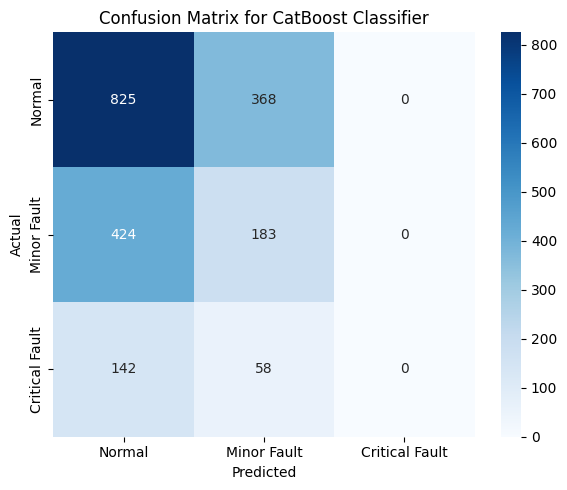

C:\Users\User\AppData\Local\Temp\ipykernel_20364\3981404737.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importances, palette="viridis")


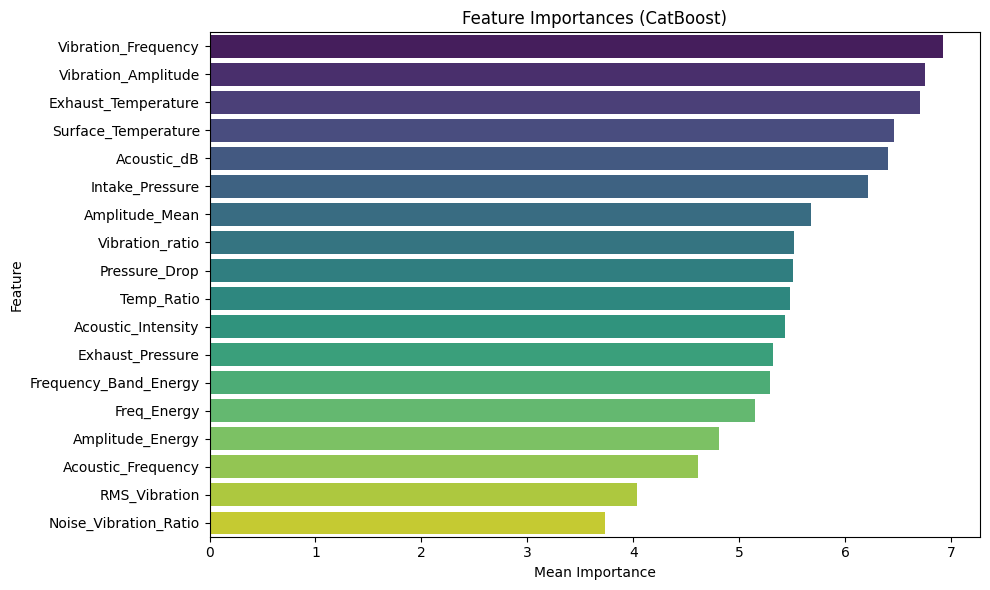

In [ ]:
#this section attempts catboost 
#import pandas as pd
from catboost import CatBoostClassifier
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
#import seaborn as sns
#import matplotlib.pyplot as plt

#CatBoost Classifier Setup
cat_model = CatBoostClassifier(
    iterations=500,                  # Number of boosting iterations
    learning_rate=0.05,              # Controls the step size at each iteration
    depth=6,                         # Depth of the tree (balances complexity and overfitting)
    l2_leaf_reg=3,                   # L2 regularization to penalize large leaf values
    eval_metric='Accuracy',          # Metric to optimize
    random_seed=42,
    verbose=False                    # Suppress training output
)

#Train the Model
cat_model.fit(X_train, y_train)

#Evaluate on Test Set
y_test_pred = cat_model.predict(X_test)
test_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy (CatBoost): {test_acc:.4f}")
print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_test_pred))

#Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Minor Fault", "Critical Fault"],
    yticklabels=["Normal", "Minor Fault", "Critical Fault"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for CatBoost Classifier")
plt.tight_layout()
plt.show()

#Feature Importance Plot
feature_importances = pd.DataFrame(
    {"Feature": X.columns, "Importance": cat_model.feature_importances_}
)
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importances, palette="viridis")
plt.title("Feature Importances (CatBoost)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()


[I 2025-03-31 15:14:15,200] A new study created in memory with name: no-name-69da7525-07b8-426e-a99f-ae03e598883b


[I 2025-03-31 15:14:19,471] Trial 0 finished with value: 0.1705 and parameters: {'iterations': 500, 'learning_rate': 0.09566789831855556, 'depth': 6, 'l2_leaf_reg': 4.507338750686383, 'class_weight_0': 2.154659204414894, 'class_weight_1': 9.432704768919216, 'class_weight_2': 28.710027188194584}. Best is trial 0 with value: 0.1705.
[I 2025-03-31 15:14:28,137] Trial 1 finished with value: 0.3385 and parameters: {'iterations': 600, 'learning_rate': 0.04080137002903086, 'depth': 7, 'l2_leaf_reg': 0.003344805397020932, 'class_weight_0': 3.355500118426058, 'class_weight_1': 8.184040721370835, 'class_weight_2': 14.67779212312425}. Best is trial 1 with value: 0.3385.
[I 2025-03-31 15:14:30,977] Trial 2 finished with value: 0.523 and parameters: {'iterations': 200, 'learning_rate': 0.013781377169055435, 'depth': 7, 'l2_leaf_reg': 0.24934236541047408, 'class_weight_0': 4.542455701579605, 'class_weight_1': 3.010510757410092, 'class_weight_2': 26.47748653701635}. Best is trial 2 with value: 0.523.

Best Parameters Found:
{'iterations': 200, 'learning_rate': 0.013781377169055435, 'depth': 7, 'l2_leaf_reg': 0.24934236541047408, 'class_weight_0': 4.542455701579605, 'class_weight_1': 3.010510757410092, 'class_weight_2': 26.47748653701635}
0:	learn: 0.4616269	test: 0.4317252	best: 0.4317252 (0)	total: 14.5ms	remaining: 2.89s
50:	learn: 0.6554687	test: 0.4320793	best: 0.4697829 (9)	total: 712ms	remaining: 2.08s
100:	learn: 0.6994103	test: 0.4320793	best: 0.4697829 (9)	total: 1.41s	remaining: 1.38s
150:	learn: 0.7223956	test: 0.4320793	best: 0.4697829 (9)	total: 2.1s	remaining: 683ms
199:	learn: 0.7350058	test: 0.4320793	best: 0.4697829 (9)	total: 2.77s	remaining: 0us

bestTest = 0.46978294
bestIteration = 9

Shrink model to first 10 iterations.

Final Test Accuracy (Optimized CatBoost): 0.5230

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.61      0.83      0.70      1193
           1       0.00      0.00      0.00       6

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

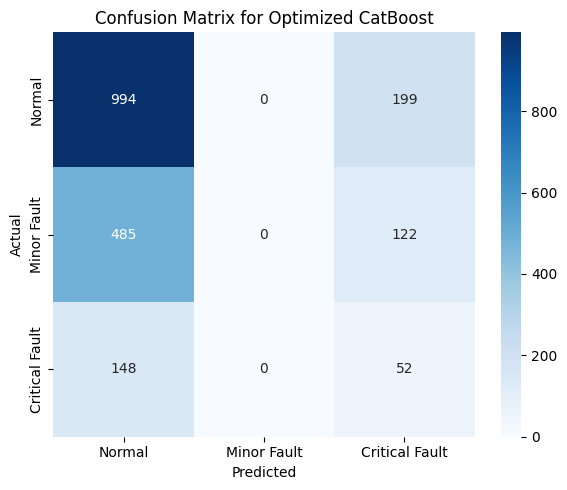

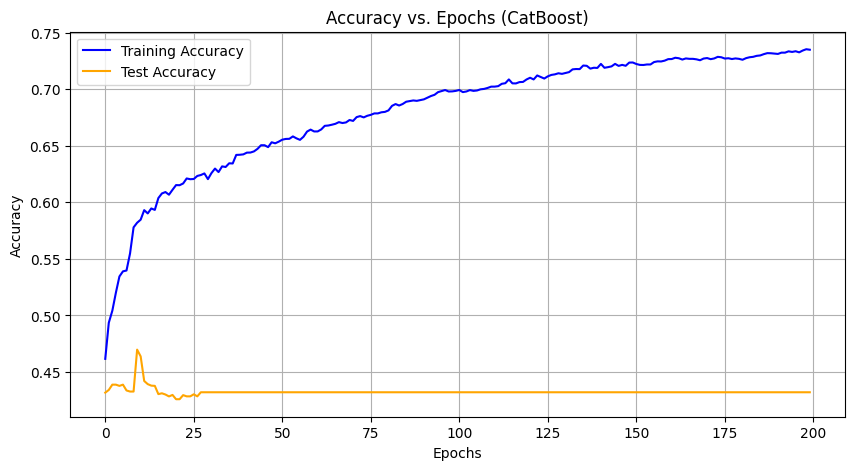

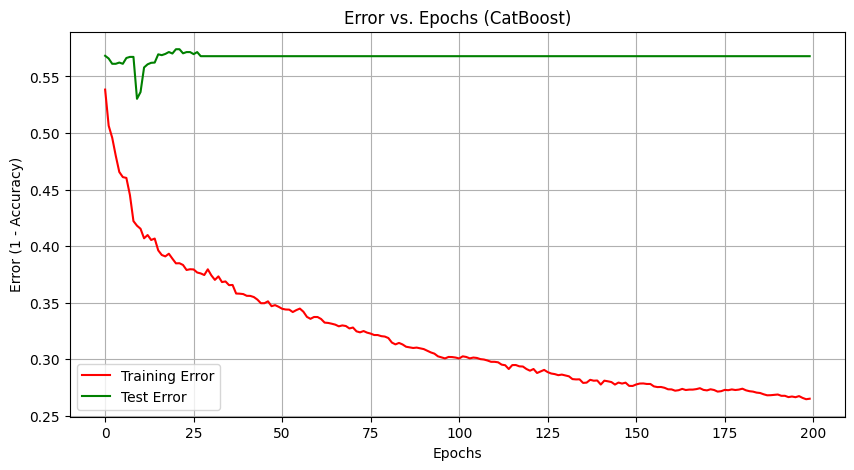

In [ ]:
# This section attempts to do catboost optimization + class weights optimization I tried with [1,3,6] but the results weren't great
#import optuna
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
#from catboost import CatBoostClassifier
#from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score

# Define the objective function for Optuna
def objective(trial):
    # Define hyperparameters to be optimized
    iterations = trial.suggest_int("iterations", 100, 700, step=100)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True)
    
    # Suggest class weights to balance the class imbalance
    class_weight_0 = trial.suggest_float("class_weight_0", 1.0, 5.0)
    class_weight_1 = trial.suggest_float("class_weight_1", 2, 10)
    class_weight_2 = trial.suggest_float("class_weight_2", 6, 30)
    class_weights = [class_weight_0, class_weight_1, class_weight_2]

    # Initialize and train CatBoost with the suggested parameters
    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        class_weights=class_weights, #3,7,16 maybe
        verbose=0,
        eval_metric="Accuracy",
        random_state=42
    )
    
    cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    # Predict on the test set
    y_pred = model.predict(X_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    return acc

# Run Optuna with trials to optimize CatBoost
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5) #5 trials to avoid long wait times when re-run

# Get the best parameters from the Optuna study
best_params = study.best_params
print("Best Parameters Found:")
print(best_params)

# Extract the best class weights
best_class_weights = [
    best_params["class_weight_0"],
    best_params["class_weight_1"],
    best_params["class_weight_2"]
]

# Train the final CatBoost model with the best parameters
final_model = CatBoostClassifier(
    iterations=best_params["iterations"],
    learning_rate=best_params["learning_rate"],
    depth=best_params["depth"],
    l2_leaf_reg=best_params["l2_leaf_reg"],
    class_weights=best_class_weights,
    verbose=100,
    eval_metric="Accuracy",
    random_state=42
)

# Fit the final model on the training data
final_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=50)

# Predict on the test set
y_pred_test = final_model.predict(X_test)

# Calculate test accuracy and display classification report
test_acc = balanced_accuracy_score(y_test, y_pred_test)
print(f"\nFinal Test Accuracy (Optimized CatBoost): {test_acc:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

# Plot confusion matrix for test set
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Minor Fault", "Critical Fault"],
            yticklabels=["Normal", "Minor Fault", "Critical Fault"])
plt.title("Confusion Matrix for Optimized CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Capture and plot accuracy and error vs. epochs
# Capture and plot log loss vs. epochs
eval_results = final_model.get_evals_result()

# Extract log loss for training
train_accuracy = np.array(eval_results["learn"]["Accuracy"])
test_accuracy = np.array(eval_results["validation"]["Accuracy"])
iterations_range = np.arange(len(train_accuracy))

# Plot log loss vs. epochs
plt.figure(figsize=(10, 5))
plt.plot(iterations_range, train_accuracy, label="Training Accuracy", color="blue")
plt.plot(iterations_range, test_accuracy, label="Test Accuracy", color="orange")
plt.title("Accuracy vs. Epochs (CatBoost)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Error Plot (1 - Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(iterations_range, 1 - np.array(train_accuracy), label="Training Error", color="red")
plt.plot(iterations_range, 1 - np.array(test_accuracy), label="Test Error", color="green")
plt.xlabel("Epochs")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Error vs. Epochs (CatBoost)")
plt.legend()
plt.grid(True)
plt.show()
#~

In [36]:
#This section saves the results to csv
#import os

results_file_path = "catboost_optuna_results.csv"
# Create a list to store study results
study_results = []

# Loop through all trials and save results
for trial in study.trials:
    study_results.append({
        "trial_number": trial.number,
        "iterations": trial.params["iterations"],
        "learning_rate": trial.params["learning_rate"],
        "depth": trial.params["depth"],
        "l2_leaf_reg": trial.params["l2_leaf_reg"],
        "class_weight_0": trial.params["class_weight_0"],
        "class_weight_1": trial.params["class_weight_1"],
        "class_weight_2": trial.params["class_weight_2"],
        "f1_score": trial.value
    })

# Convert the results to a DataFrame
results_df = pd.DataFrame(study_results)

# Check if the file already exists to append data instead of overwriting
if os.path.exists(results_file_path):
    # Read the existing file to append new data
    existing_df = pd.read_csv(results_file_path)
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save results to CSV (append if file exists, create otherwise)
results_df.to_csv(results_file_path, index=False)

print(f"\nStudy results successfully saved to '{results_file_path}'")



Study results successfully saved to 'catboost_optuna_results.csv'


[I 2025-03-30 23:40:06,267] A new study created in memory with name: no-name-ce8d158d-b162-42ee-ae52-ecf7de52d78e
[I 2025-03-30 23:40:08,613] Trial 0 finished with value: 0.4635 and parameters: {'iterations': 250, 'learning_rate': 0.08708623055578268, 'depth': 6, 'l2_leaf_reg': 0.45319084616989136}. Best is trial 0 with value: 0.4635.
[I 2025-03-30 23:40:31,518] Trial 1 finished with value: 0.428 and parameters: {'iterations': 250, 'learning_rate': 0.0017300906210417583, 'depth': 10, 'l2_leaf_reg': 0.14614534203061147}. Best is trial 0 with value: 0.4635.
[I 2025-03-30 23:40:33,561] Trial 2 finished with value: 0.4035 and parameters: {'iterations': 350, 'learning_rate': 0.0012089926034356952, 'depth': 5, 'l2_leaf_reg': 0.0012235331439445184}. Best is trial 0 with value: 0.4635.
[I 2025-03-30 23:40:57,120] Trial 3 finished with value: 0.4955 and parameters: {'iterations': 450, 'learning_rate': 0.05614855979596863, 'depth': 9, 'l2_leaf_reg': 0.0022855957300349063}. Best is trial 3 with v


Best Parameters from Optuna:
{'iterations': 450, 'learning_rate': 0.05614855979596863, 'depth': 9, 'l2_leaf_reg': 0.0022855957300349063}
0:	learn: 0.4509434	test: 0.3280000	best: 0.3280000 (0)	total: 59ms	remaining: 26.5s
50:	learn: 0.7097135	test: 0.4400000	best: 0.4410000 (49)	total: 2.67s	remaining: 20.9s
100:	learn: 0.8079665	test: 0.4500000	best: 0.4600000 (89)	total: 5.28s	remaining: 18.2s
150:	learn: 0.8721174	test: 0.4630000	best: 0.4650000 (145)	total: 8.23s	remaining: 16.3s
200:	learn: 0.9081761	test: 0.4715000	best: 0.4735000 (199)	total: 10.8s	remaining: 13.4s
250:	learn: 0.9374563	test: 0.4795000	best: 0.4800000 (229)	total: 13.4s	remaining: 10.6s
300:	learn: 0.9596785	test: 0.4815000	best: 0.4860000 (289)	total: 16s	remaining: 7.93s
350:	learn: 0.9716981	test: 0.4865000	best: 0.4895000 (331)	total: 18.6s	remaining: 5.25s
400:	learn: 0.9801537	test: 0.4915000	best: 0.4930000 (375)	total: 21.4s	remaining: 2.61s
449:	learn: 0.9866527	test: 0.4950000	best: 0.4955000 (431)	to

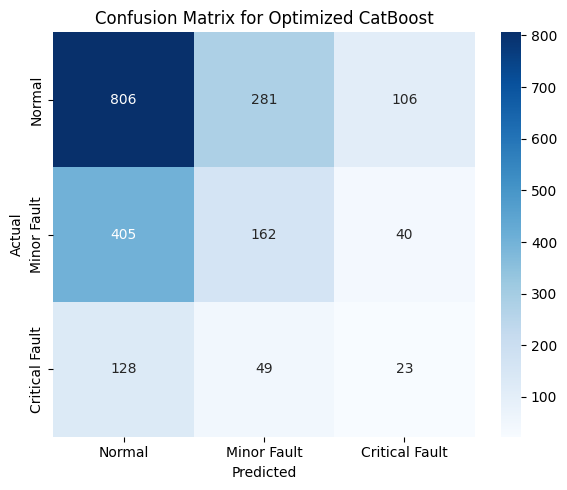

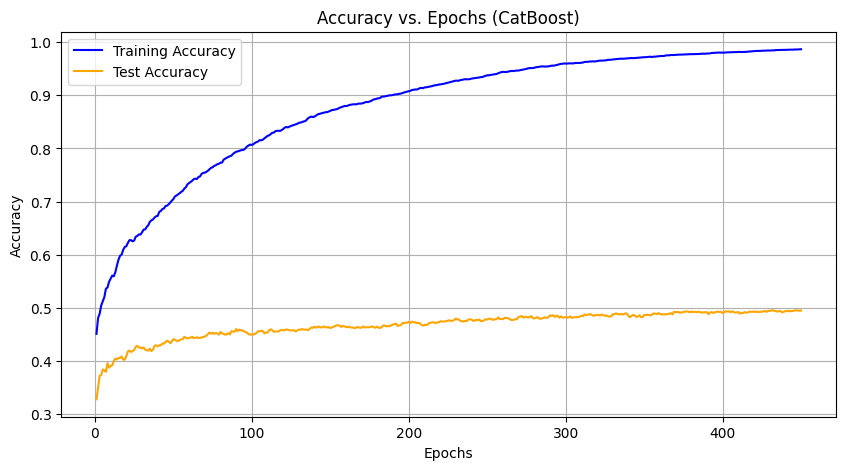

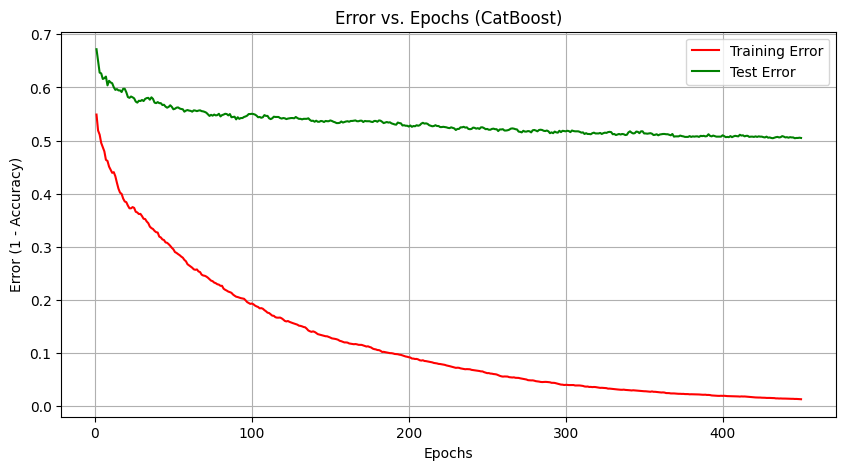

In [ ]:
# This section tries using the balanced datasets for catboost to see if there is a difference
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
#import optuna
#from catboost import CatBoostClassifier
#from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix


#Objective Function for Optuna
def objective(trial):
    # Define the search space for hyperparameters
    params = {
        "iterations": trial.suggest_int("iterations", 100, 500, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),
    }

    # Create and train CatBoost model
    cat_model = CatBoostClassifier(
        **params,
        eval_metric="Accuracy",
        verbose=False,
        random_seed=42,
    )

    # Fit and validate model using balanced dataset
    cat_model.fit(X_train_balanced, y_train_balanced, eval_set=(X_test, y_test), verbose=False)
    y_test_pred = cat_model.predict(X_test)
    acc = balanced_accuracy_score(y_test, y_test_pred)
    
    return acc

#Run Optuna Optimization
study = optuna.create_study(direction="maximize")  # Maximize accuracy
study.optimize(objective, n_trials=5, timeout=600)

# Print best parameters
print(f"\nBest Parameters from Optuna:\n{study.best_params}")
best_params = study.best_params


#Train Final Model with Optimal Parameters#
final_cat_model = CatBoostClassifier(
    iterations=best_params["iterations"],
    learning_rate=best_params["learning_rate"],
    depth=best_params["depth"],
    l2_leaf_reg=best_params["l2_leaf_reg"],
    eval_metric="Accuracy",
    verbose=False,
    random_seed=42,
)

# Fit the model and record performance over iterations
final_cat_model.fit(X_train_balanced, y_train_balanced, eval_set=(X_test, y_test), verbose=50)

#Evaluate on Test Set#
y_test_pred = final_cat_model.predict(X_test)
test_acc = balanced_accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy (CatBoost): {test_acc:.4f}")
print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_test_pred))

#Confusion Matrix#
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Minor Fault", "Critical Fault"],
    yticklabels=["Normal", "Minor Fault", "Critical Fault"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Optimized CatBoost")
plt.tight_layout()
plt.show()

#Plot Accuracy and Error vs. Epochs#
# Extract learning curves from CatBoost
eval_results = final_cat_model.get_evals_result()
train_acc = eval_results['learn']['Accuracy']
test_acc = eval_results['validation']['Accuracy']
epochs = np.arange(1, best_params["iterations"] + 1)

# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label="Training Accuracy", color="blue")
plt.plot(epochs, test_acc, label="Test Accuracy", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epochs (CatBoost)")
plt.legend()
plt.grid(True)
plt.show()

# Error Plot (1 - Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(epochs, 1 - np.array(train_acc), label="Training Error", color="red")
plt.plot(epochs, 1 - np.array(test_acc), label="Test Error", color="green")
plt.xlabel("Epochs")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Error vs. Epochs (CatBoost)")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
#import os

# Extract results from Optuna study as a DataFrame
study_results_df = study.trials_dataframe()

# Add custom information to the DataFrame for easier tracking
study_results_df["final_test_accuracy"] = test_acc
study_results_df["best_iterations"] = best_params["iterations"]
study_results_df["best_learning_rate"] = best_params["learning_rate"]
study_results_df["best_depth"] = best_params["depth"]
study_results_df["best_l2_leaf_reg"] = best_params["l2_leaf_reg"]

# Define the output file path
results_file = "catboost_balanced_dataset_optuna_results.csv"

# Check if the file exists
if os.path.exists(results_file):
    # Append results to the existing file without overwriting
    study_results_df.to_csv(results_file, mode="a", header=False, index=False)
    print(f"Results appended to {results_file}")
else:
    # Save as a new CSV if the file does not exist
    study_results_df.to_csv(results_file, index=False)
    print(f"Results saved to {results_file}")


Results appended to catboost_optuna_results.csv


### **Hyperparameter Optimization for MLP**
This program uses **Latin Hypercube Sampling (LHS)** to efficiently explore different neural network architectures.
It varies:
- **Layer width** (number of neurons per layer)
- **Depth** (number of hidden layers)
- **Max iterations** (training epochs)
The goal is to find the best configuration for **engine fault classification**.

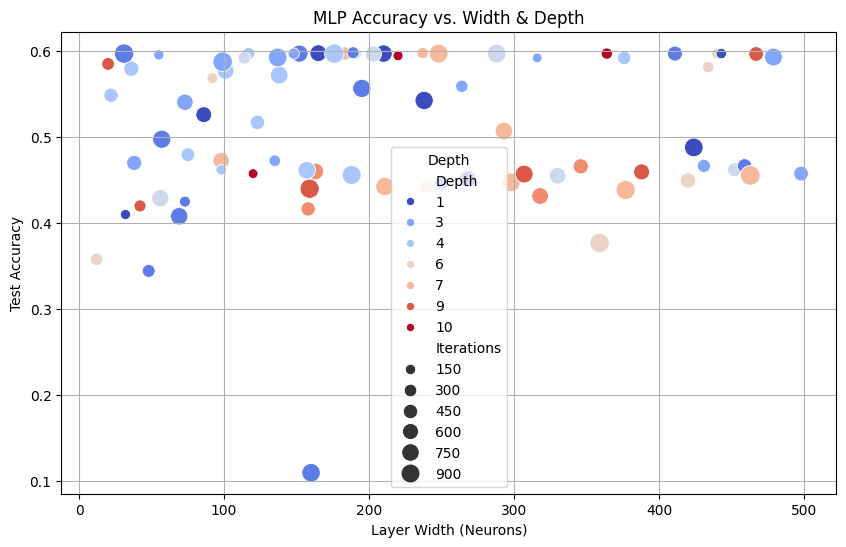

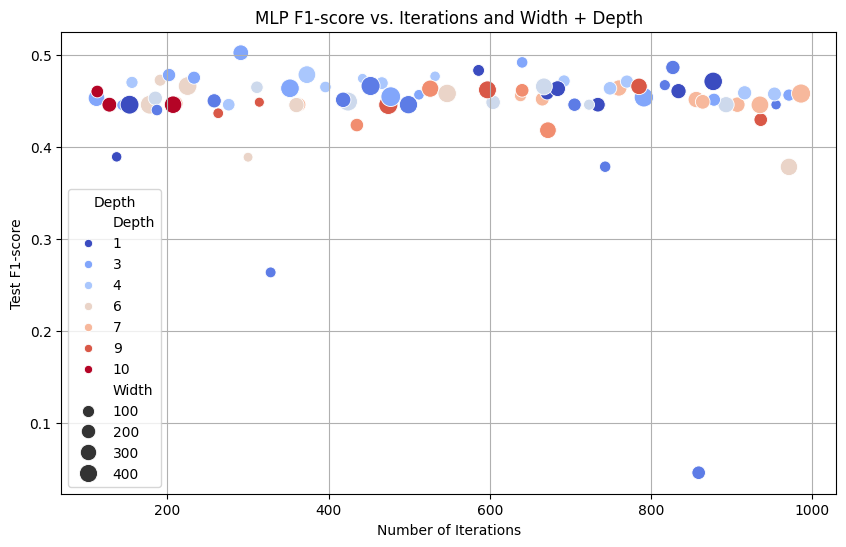


Best Model Configuration:
Width         264.0000
Depth           3.0000
Iterations    291.0000
Accuracy        0.5585
F1-score        0.5021
Name: 0, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score
from pyDOE3 import lhs  # Latin Hypercube Sampling

'''
#Step 1: Generate Hyperparameter Samples using Latin Hypercube Sampling
# Define ranges for hyperparameters
n_samples = 25  # Number of MLP configurations to test
width_range = (5, 500)  # Neurons per layer
depth_range = (1, 10)  # Number of hidden layers
iterations_range = (100, 1000)  # Training epochs

# Generate Latin Hypercube Samples
lhs_samples = lhs(3, samples=n_samples)  # 3 hyperparameters

# Scale LHS values to match actual ranges
width_samples = np.round(lhs_samples[:, 0] * (width_range[1] - width_range[0]) + width_range[0]).astype(int)
depth_samples = np.round(lhs_samples[:, 1] * (depth_range[1] - depth_range[0]) + depth_range[0]).astype(int)
iterations_samples = np.round(lhs_samples[:, 2] * (iterations_range[1] - iterations_range[0]) + iterations_range[0]).astype(int)

# Store hyperparameter configurations
hyperparameter_configs = pd.DataFrame({
    "Width": width_samples,
    "Depth": depth_samples,
    "Iterations": iterations_samples
})


#Step 2: Train and Evaluate MLP Models
# Store results
results = []

for i, row in hyperparameter_configs.iterrows():
    width, depth, iterations = row["Width"], row["Depth"], row["Iterations"]
    
    # Define hidden layer structure
    hidden_layers = tuple([width] * depth)  # Example: (100, 100) for depth=2
    
    # Initialize MLP
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layers,
                        activation='relu',
                        solver='adam',
                        max_iter=iterations,
                        random_state=42)

    # Train model
    mlp.fit(X_train_balanced, y_train_balanced)
    
    # Predict on test set
    y_pred = mlp.predict(X_test)

    # Evaluate performance
    accuracy = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results.append([width, depth, iterations, accuracy, f1])
    print(f"Tested MLP {i+1}/{n_samples} | Width: {width}, Depth: {depth}, Iterations: {iterations} → Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}")
'''

# Convert to DataFrame
# Raw data extracted from the output logs
results = [
    (264, 3, 291, 0.5585, 0.5021),
    (424, 1, 877, 0.4875, 0.4710),
    (237, 7, 210, 0.5970, 0.4469),
    (376, 4, 373, 0.5915, 0.4783),
    (159, 9, 936, 0.4395, 0.4294),
    (359, 6, 971, 0.3765, 0.3782),
    (175, 7, 665, 0.5960, 0.4518),
    (195, 2, 827, 0.5560, 0.4861),
    (36, 4, 532, 0.5790, 0.4765),
    (440, 6, 178, 0.5965, 0.4457),
    (210, 1, 734, 0.5965, 0.4457),
    (152, 2, 705, 0.5965, 0.4457),
    (248, 7, 907, 0.5965, 0.4457),
    (158, 8, 435, 0.4160, 0.4236),
    (203, 5, 604, 0.5960, 0.4483),
    (293, 7, 760, 0.5065, 0.4638),
    (316, 3, 112, 0.5915, 0.4528),
    (479, 3, 791, 0.5925, 0.4537),
    (288, 5, 893, 0.5965, 0.4457),
    (117, 4, 276, 0.5965, 0.4457),
    (452, 5, 424, 0.4615, 0.4491),
    (434, 6, 225, 0.5810, 0.4659),
    (69, 2, 743, 0.4075, 0.3784),
    (220, 10, 128, 0.5940, 0.4457),
    (92, 6, 191, 0.5680, 0.4723),
    (318, 8, 672, 0.4310, 0.4180),
    (183, 7, 363, 0.5965, 0.4457),
    (467, 9, 474, 0.5960, 0.4455),
    (55, 3, 144, 0.5950, 0.4453),
    (411, 2, 499, 0.5965, 0.4457),
    (98, 7, 638, 0.4720, 0.4555),
    (443, 1, 153, 0.5965, 0.4457),
    (20, 9, 314, 0.5845, 0.4484),
    (31, 2, 955, 0.5965, 0.4457),
    (238, 1, 834, 0.5420, 0.4604),
    (364, 10, 207, 0.5965, 0.4457),
    (101, 4, 692, 0.5765, 0.4714),
    (22, 4, 442, 0.5480, 0.4742),
    (148, 3, 202, 0.5965, 0.4779),
    (160, 2, 859, 0.1095, 0.0463),
    (32, 1, 137, 0.4095, 0.3891),
    (73, 3, 640, 0.5400, 0.4916),
    (165, 1, 671, 0.5970, 0.4583),
    (99, 3, 971, 0.5870, 0.4561),
    (191, 5, 185, 0.5960, 0.4527),
    (123, 4, 466, 0.5165, 0.4691),
    (138, 4, 770, 0.5715, 0.4708),
    (137, 3, 878, 0.5920, 0.4511),
    (114, 5, 311, 0.5915, 0.4646),
    (86, 1, 586, 0.5255, 0.4829),
    (176, 4, 953, 0.5965, 0.4573),
    (38, 3, 512, 0.4695, 0.4565),
    (75, 4, 396, 0.4790, 0.4649),
    (48, 2, 328, 0.3440, 0.2637),
    (57, 2, 817, 0.4970, 0.4669),
    (189, 2, 258, 0.5975, 0.4499),
    (298, 7, 856, 0.4470, 0.4513),
    (431, 3, 352, 0.4660, 0.4635),
    (163, 8, 640, 0.4595, 0.4613),
    (459, 2, 452, 0.4660, 0.4660),
    (98, 4, 156, 0.4615, 0.4699),
    (56, 5, 723, 0.4285, 0.4457),
    (307, 9, 785, 0.4565, 0.4656),
    (12, 6, 300, 0.3575, 0.3887),  # Convergence warning included but doesn't affect data
    (157, 4, 749, 0.4610, 0.4635),
    (135, 3, 233, 0.4720, 0.4750),
    (240, 6, 360, 0.4420, 0.4453),
    (211, 7, 864, 0.4420, 0.4488),
    (120, 10, 113, 0.4570, 0.4600),
    (463, 7, 986, 0.4550, 0.4578),
    (346, 8, 526, 0.4655, 0.4631),
    (498, 3, 477, 0.4570, 0.4544),
    (268, 1, 684, 0.4505, 0.4631),
    (42, 9, 263, 0.4195, 0.4364),
    (250, 2, 418, 0.4460, 0.4510),
    (388, 9, 597, 0.4590, 0.4618),
    (420, 6, 547, 0.4490, 0.4579),
    (73, 2, 187, 0.4245, 0.4399),  # Convergence warning included but doesn't affect data
    (330, 5, 667, 0.4545, 0.4655),
    (377, 7, 935, 0.4380, 0.4455),
    (188, 4, 916, 0.4555, 0.4586)
]
results_df = pd.DataFrame(results, columns=["Width", "Depth", "Iterations", "Accuracy", "F1-score"])

#Step 3: Analyze Results with Graphs
# Plot Accuracy vs. Hyperparameters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="Width", y="Accuracy", hue="Depth", size="Iterations", palette="coolwarm", sizes=(50, 200))
plt.xlabel("Layer Width (Neurons)")
plt.ylabel("Test Accuracy")
plt.title("MLP Accuracy vs. Width & Depth")
plt.legend(title="Depth")
plt.grid(True)
plt.show()

# Plot F1-score vs. Hyperparameters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="Iterations", y="F1-score", hue="Depth", size="Width", palette="coolwarm", sizes=(50, 200))
plt.xlabel("Number of Iterations")
plt.ylabel("Test F1-score")
plt.title("MLP F1-score vs. Iterations and Width + Depth")
plt.legend(title="Depth")
plt.grid(True)
plt.show()

# Step 4: Find the Best Model Configuration
# Sort results by best F1-score
best_config = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
print("\nBest Model Configuration:")
print(best_config)

# Save results to CSV for further analysis
results_df.to_csv("mlp_results.csv", index=False)

The best MLP model achieved 55.85% accuracy and an F1-score of 50.21%, which is not sufficient for a reliable engine fault classification system. Now, I will need to decide:

- Option 1: Try a Different Model (Alternative Modern Methods)
- Option 2: Improve Hyperparameter Tuning for MLP



I will try using **Random Forest (RF)**
- RF is an ensemble method that can handle non-linear data well.
- It provides feature importance, helping us determine which sensor readings matter.
- It avoids overfitting better than deep neural networks.
<br><br>
Why RF Might Work Better?
- Less sensitive to class imbalance than MLP.
- Better interpretability → We can see what features drive - fault predictions.
- Less hyperparameter tuning required.

Noisy Data: Measurement errors or mislabeling.
Insufficient Features: Lack of necessary information to make correct predictions.
Ambiguous Labels: Some examples may have no clear correct label.
Wrong Inductive Bias: If a model's assumptions are misaligned with the true data patterns.